# Неделя 1 — EDA

Карточка недели: `docs/week1_eda.md` · Полное описание: тетрадь, раздел 5

**Конвенция ячеек:**
- ячейка без пометки — готовый код, просто запустите
- `# TODO:` — здесь пишете вы

## 1. Загрузка данных

Читаем `.xlsx` и 30 CSV один раз, сохраняем в parquet. Дальше во всех ноутбуках читаем только parquet.

In [18]:
import glob
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append('..')
from src.eda import churn_rate_by, explore, missing_months

In [19]:
clients = pd.read_excel('../data/raw/clients.xlsx')

usage_files = sorted(glob.glob('../data/raw/usage/*.csv'))
usage = pd.concat([pd.read_csv(f) for f in usage_files], ignore_index=True)

clients.to_parquet('../data/processed/clients.parquet')
usage.to_parquet('../data/processed/usage.parquet')

print(clients.shape)   # ожидаем (50400, 8)
print(usage.shape)     # ожидаем (1073079, 7)

(50400, 8)
(1073079, 7)


## 2. Профилирование

`explore()` уже написана — применяем. Прочитайте вывод: по нему вы отвечаете на половину вопросов ниже.

In [20]:
explore(clients, 'Клиенты')

===== Клиенты =====
Размер: 50400 строк, 8 столбцов
                  тип  пропусков  пропусков_%  уникальных
client_id         str          0          0.0       50400
segment           str          0          0.0           3
product           str          0          0.0           4
region            str          0          0.0           5
company_name      str          0          0.0       19360
connection_date   str          0          0.0          58
termination_date  str      36361         72.1          27
current_status    str          0          0.0           2


,тип,пропусков,пропусков_%,уникальных
client_id,str,0,0.0,50400
segment,str,0,0.0,3
product,str,0,0.0,4
region,str,0,0.0,5
company_name,str,0,0.0,19360
connection_date,str,0,0.0,58
termination_date,str,36361,72.1,27
current_status,str,0,0.0,2


In [21]:
explore(usage, 'Потребление')

===== Потребление =====
Размер: 1073079 строк, 7 столбцов
                тип  пропусков  пропусков_%  уникальных
client_id       str          0          0.0       50400
month           str          0          0.0          30
revenue     float64          0          0.0     1016925
traffic_gb  float64          0          0.0       26650
n_tickets     int64          0          0.0          13
debt        float64          0          0.0       76454
n_sim         int64          0          0.0         348

--- Числовые столбцы ---
                count       mean        std   min       25%       50%  \
revenue     1073079.0  195748.37  405595.09  5.61  11491.77  36753.69   
traffic_gb  1073079.0     193.76     407.92  0.00     11.20     36.00   
n_tickets   1073079.0       0.33       0.70  0.00      0.00      0.00   
debt        1073079.0     109.15     401.86  0.00      0.00      0.00   
n_sim       1073079.0      34.80      68.70  0.00      2.00      5.00   

                  75%        

,тип,пропусков,пропусков_%,уникальных
client_id,str,0,0.0,50400
month,str,0,0.0,30
revenue,float64,0,0.0,1016925
traffic_gb,float64,0,0.0,26650
n_tickets,int64,0,0.0,13
debt,float64,0,0.0,76454
n_sim,int64,0,0.0,348


## 3. Дыры в помесячных данных

Здесь нужна ваша функция `missing_months` из `src/eda.py`.

In [22]:
gaps = missing_months(usage)
print('клиентов с дырами внутри периода:', gaps['has_gap'].sum())
print('доля клиентов с дырами:', gaps['has_gap'].mean())
gaps.head()

клиентов с дырами внутри периода: 0
доля клиентов с дырами: 0.0


,first_month,last_month,n_months_actual,n_months_expected,has_gap
client_id,,,,,
CL000001,2024-01,2026-06,30,30,False
CL000002,2024-01,2025-09,21,21,False
CL000003,2024-01,2024-06,6,6,False
CL000004,2024-07,2026-06,24,24,False
CL000005,2026-01,2026-04,4,4,False


In [23]:
gaps_df = missing_months(usage)

print("Проверка дыр в истории клиентов")
print(f"Всего клиентов: {len(gaps_df)}")
print(f"Клиентов с дырами: {gaps_df['has_gap'].sum()} ({gaps_df['has_gap'].mean():.2%})")
print(f"Клиентов без дыр: {(~gaps_df['has_gap']).sum()} ({(~gaps_df['has_gap']).mean():.2%})")

print(f"\nДлина истории клиента (фактическое количество месяцев):")
print(f"  Минимум: {gaps_df['n_months_actual'].min()} месяцев")
print(f"  Максимум: {gaps_df['n_months_actual'].max()} месяцев")
print(f"  Медиана: {gaps_df['n_months_actual'].median()} месяцев")

gaps_only = gaps_df[gaps_df['has_gap']]
if len(gaps_only) > 0:
    print(f"\nПримеры клиентов с дырами (первые 5):")
    display(gaps_only[['first_month', 'last_month', 'n_months_actual', 'n_months_expected']].head(5))

Проверка дыр в истории клиентов
Всего клиентов: 50400
Клиентов с дырами: 0 (0.00%)
Клиентов без дыр: 50400 (100.00%)

Длина истории клиента (фактическое количество месяцев):
  Минимум: 3 месяцев
  Максимум: 30 месяцев
  Медиана: 24.0 месяцев


## 4. Семь вопросов недели

Список вопросов — тетрада 5.3, шаг 4. Считайте здесь, ответы текстом пишите в журнале.

Каждый ответ — 1–3 предложения **с числом**.

In [24]:
#1: Что является строкой?
print("clients")
print(f"Строк: {len(clients)}")
print(f"Уникальных client_id: {clients['client_id'].nunique()}")
print(f"Строка = уникальный клиент (client_id уникален)")

print("\nusage")
print(f"Строк: {len(usage)}")
print(f"Уникальных пар (client_id, month): {usage[['client_id', 'month']].drop_duplicates().shape[0]}")
print(f"Строка = потребление одного клиента за один месяц")

#2: Ключ связи и доля склейки
print("\nКлюч связи")
print(f"Ключ: client_id")
print(f"Доля client_id из usage в clients: {usage['client_id'].isin(clients['client_id']).mean():.4f}")
print(f"Доля client_id из clients в usage: {clients['client_id'].isin(usage['client_id']).mean():.4f}")

# Проверка склейки через merge с indicator
merge_check = usage[['client_id']].drop_duplicates().merge(
    clients[['client_id']],
    on='client_id',
    how='outer',
    indicator=True
)
print("\nПроверка склейки через merge")
print(merge_check['_merge'].value_counts())

#3: Период и дыры
print("\nПериод по clients")
clients['connection_date_dt'] = pd.to_datetime(clients['connection_date'], errors='coerce')
clients['termination_date_dt'] = pd.to_datetime(clients['termination_date'], errors='coerce')

print(f"Первое подключение: {clients['connection_date_dt'].min()}")
print(f"Последнее подключение: {clients['connection_date_dt'].max()}")
print(f"Первое расторжение: {clients['termination_date_dt'].min()}")
print(f"Последнее расторжение: {clients['termination_date_dt'].max()}")

print("\nПодключения по месяцам (последние 8):")
print(clients['connection_date_dt'].dt.to_period('M').value_counts().sort_index().tail(8))

print("\nДыры в usage")
gaps = missing_months(usage)
print(f"Клиентов с дырами: {gaps['has_gap'].sum()} из {len(gaps)}")
print(f"Доля клиентов с дырами: {gaps['has_gap'].mean():.2%}")
print(f"Длина истории: от {gaps['n_months_actual'].min()} до {gaps['n_months_actual'].max()} месяцев, медиана {gaps['n_months_actual'].median()}")

clients
Строк: 50400
Уникальных client_id: 50400
Строка = уникальный клиент (client_id уникален)

usage
Строк: 1073079
Уникальных пар (client_id, month): 1073079
Строка = потребление одного клиента за один месяц

Ключ связи
Ключ: client_id
Доля client_id из usage в clients: 1.0000
Доля client_id из clients в usage: 1.0000

Проверка склейки через merge
_merge
both          50400
left_only         0
right_only        0
Name: count, dtype: int64

Период по clients
Первое подключение: 2021-07-01 00:00:00
Последнее подключение: 2026-04-01 00:00:00
Первое расторжение: 2024-04-01 00:00:00
Последнее расторжение: 2026-06-01 00:00:00

Подключения по месяцам (последние 8):
connection_date_dt
2025-09    900
2025-10    872
2025-11    912
2025-12    926
2026-01    934
2026-02    930
2026-03     28
2026-04     27
Freq: M, Name: count, dtype: int64

Дыры в usage
Клиентов с дырами: 0 из 50400
Доля клиентов с дырами: 0.00%
Длина истории: от 3 до 30 месяцев, медиана 24.0


In [25]:
# 4: Как виден отток?
print("Отток в clients")
clients['is_churned'] = clients['termination_date'].notna().astype(int)
print(f"Клиентов с заполненным termination_date: {clients['is_churned'].sum()} ({clients['is_churned'].mean():.2%})")

#Тихий отток: клиенты без termination_date, но с резким падением revenue
print("\nТихий отток")
usage['month_dt'] = pd.to_datetime(usage['month'])
last_month = usage['month_dt'].max()
recent_months = usage[usage['month_dt'] >= last_month - pd.DateOffset(months=2)]

rev_all = usage.groupby('client_id')['revenue'].mean()
rev_recent = recent_months.groupby('client_id')['revenue'].mean()

no_term = clients[clients['termination_date'].isna()]['client_id']
quiet_churn = []
for cid in no_term:
    if cid in rev_recent.index and cid in rev_all.index:
        if rev_all[cid] > 0 and rev_recent[cid] / rev_all[cid] < 0.2:
            quiet_churn.append(cid)

print(f"Клиентов с тихим оттоком: {len(quiet_churn)}")
print(f"Всего ушло (явный + тихий): {clients['is_churned'].sum() + len(quiet_churn)}")

#5: Сегменты, продукты, регионы
print("\nДоля оттока по сегментам")
display(churn_rate_by(clients, target_col='is_churned', group_col='segment'))

print("\nДоля оттока по продуктам")
display(churn_rate_by(clients, target_col='is_churned', group_col='product'))

print("\nДоля оттока по регионам")
display(churn_rate_by(clients, target_col='is_churned', group_col='region'))

Отток в clients
Клиентов с заполненным termination_date: 14039 (27.86%)

Тихий отток
Клиентов с тихим оттоком: 2101
Всего ушло (явный + тихий): 16140

Доля оттока по сегментам


,доля_оттока,клиентов
segment,,
малый бизнес,0.308758,24388
средний бизнес,0.275953,17079
крупный бизнес,0.201052,8933



Доля оттока по продуктам


,доля_оттока,клиентов
product,,
мобильная связь,0.279978,12676
облачные сервисы,0.279628,12463
телефония,0.279243,12627
интернет,0.275368,12634



Доля оттока по регионам


,доля_оттока,клиентов
region,,
Юг,0.285502,10105
Москва,0.281824,9914
Урал,0.276446,10096
Санкт-Петербург,0.275450,10118
Сибирь,0.273630,10167


In [26]:
#6: Дубликаты
print("Дубликаты")
print(f"Дубликатов client_id в clients: {clients['client_id'].duplicated().sum()} из {len(clients)} строк")
print(f"Дубликатов (client_id, month) в usage: {usage.duplicated(subset=['client_id', 'month']).sum()} из {len(usage)} строк")
print(f"Полных дубликатов строк в usage: {usage.duplicated().sum()}")

#7: Аномалии
print("\nАномалии в числовых полях")
print(f"Отрицательная выручка (revenue < 0): {(usage['revenue'] < 0).sum()} строк")
print(f"Нулевая выручка (revenue == 0): {(usage['revenue'] == 0).sum()} строк")
print(f"n_sim = 0: {(usage['n_sim'] == 0).sum()} строк")

zero_sim = usage[usage['n_sim'] == 0]
print(f"Из них с revenue > 1000: {(zero_sim['revenue'] > 1000).sum()} строк")

print("\nВыбросы в revenue по сегментм")
print(usage.merge(clients[['client_id', 'segment']], on='client_id')
      .groupby('segment')['revenue']
      .median()
      .round(0))

Дубликаты
Дубликатов client_id в clients: 0 из 50400 строк
Дубликатов (client_id, month) в usage: 0 из 1073079 строк
Полных дубликатов строк в usage: 0

Аномалии в числовых полях
Отрицательная выручка (revenue < 0): 0 строк
Нулевая выручка (revenue == 0): 0 строк
n_sim = 0: 37417 строк
Из них с revenue > 1000: 21906 строк

Выбросы в revenue по сегментм
segment
крупный бизнес    671314.0
малый бизнес       11668.0
средний бизнес     98247.0
Name: revenue, dtype: float64


## 5. Доля оттока по разрезам

На этой неделе используем грубое определение: ушёл = заполнен `termination_date`.
Колонки `is_churned` в данных нет, создаём её сами.

In [27]:
clients['is_churned'] = clients['termination_date'].notna().astype(int)

churn_rate_by(clients, target_col='is_churned', group_col='segment')

,доля_оттока,клиентов
segment,,
малый бизнес,0.308758,24388
средний бизнес,0.275953,17079
крупный бизнес,0.201052,8933


In [28]:
print(f"Общая доля оттока (с учетом тихого): {clients['is_churned'].mean():.2%}")

print("\nДоля оттока по продуктам:")
display(churn_rate_by(clients, target_col='is_churned', group_col='product'))

print("\nДоля оттока по регионам:")
display(churn_rate_by(clients, target_col='is_churned', group_col='region'))

Общая доля оттока (с учетом тихого): 27.86%

Доля оттока по продуктам:


,доля_оттока,клиентов
product,,
мобильная связь,0.279978,12676
облачные сервисы,0.279628,12463
телефония,0.279243,12627
интернет,0.275368,12634



Доля оттока по регионам:


,доля_оттока,клиентов
region,,
Юг,0.285502,10105
Москва,0.281824,9914
Урал,0.276446,10096
Санкт-Петербург,0.275450,10118
Сибирь,0.273630,10167


## 6. Как выглядит уход

Графики динамики `revenue` для 5–10 ушедших и 5–10 оставшихся клиентов.

Подсказка: ушедших выравнивайте по месяцу расторжения (ось X — «месяцев до ухода»), а не по календарю.

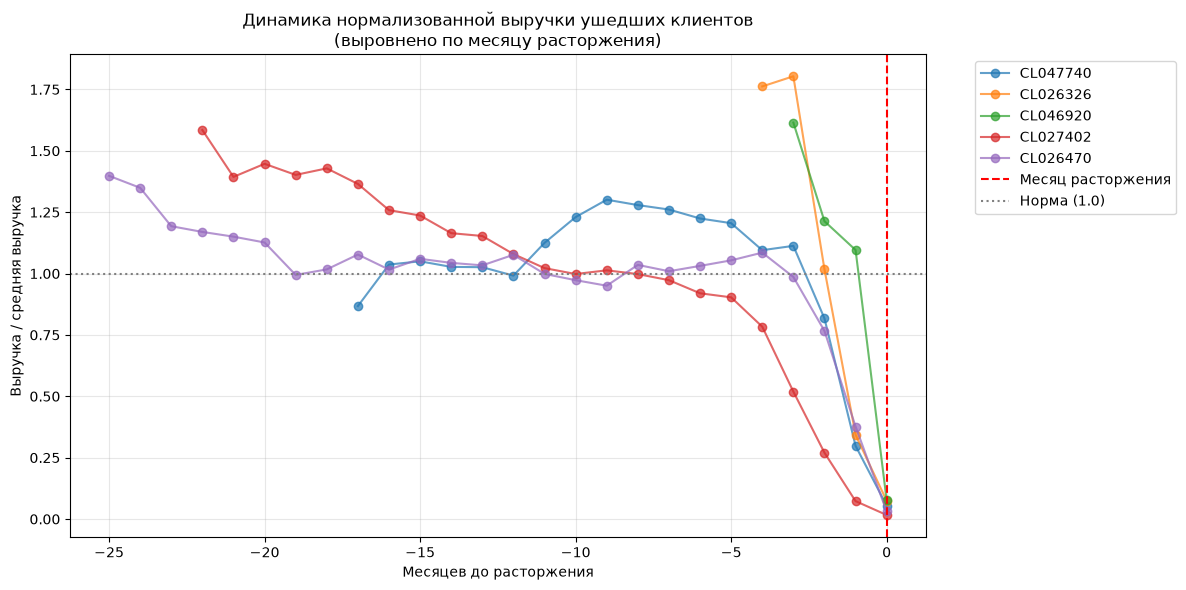

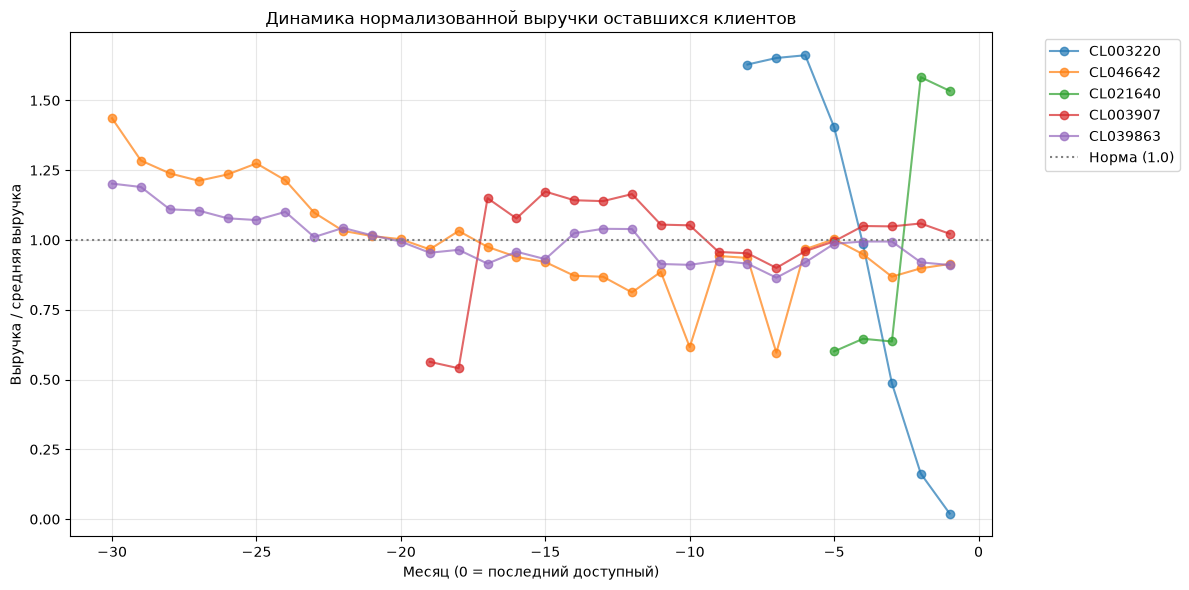

In [34]:

# Преобразуем месяц в datetime
usage["month"] = pd.to_datetime(usage["month"])

# Берем 5 ушедших клиентов
churned_ids = clients[clients["termination_date"].notna()]["client_id"].sample(5, random_state=42)

plt.figure(figsize=(12, 6))

for client_id in churned_ids:
    # История клиента
    history = usage[usage["client_id"] == client_id].sort_values("month").copy()
    
    # Дата расторжения
    term_date = clients[clients["client_id"] == client_id]["termination_date"].values[0]
    
    # Считаем месяцев до расторжения
    history["months_to_churn"] = (
        history["month"].dt.to_period("M") - pd.Period(term_date, freq="M")
    ).apply(lambda x: x.n)
    
    # Нормализуем выручку (делим на среднюю за первые месяцы)
    baseline = history["revenue"].mean()
    history["revenue_norm"] = history["revenue"] / baseline
    
    # Строим график
    plt.plot(
        history["months_to_churn"],
        history["revenue_norm"],
        marker="o",
        label=f"{client_id}",
        alpha=0.7
    )

plt.axvline(x=0, color="red", linestyle="--", label="Месяц расторжения")
plt.axhline(y=1.0, color="gray", linestyle=":", label="Норма (1.0)")
plt.title("Динамика нормализованной выручки ушедших клиентов\n(выровнено по месяцу расторжения)")
plt.xlabel("Месяцев до расторжения")
plt.ylabel("Выручка / средняя выручка")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Для оставшихся клиентов (берем случайные 5 месяцев как "якорь")
retained_ids = clients[clients["termination_date"].isna()]["client_id"].sample(5, random_state=42)

plt.figure(figsize=(12, 6))

for client_id in retained_ids:
    history = usage[usage["client_id"] == client_id].sort_values("month").copy()
    
    # Нормализуем выручку
    baseline = history["revenue"].mean()
    history["revenue_norm"] = history["revenue"] / baseline
    
    # Для оставшихся берем последние месяцы как точку отсчета
    history["months_to_end"] = range(-len(history), 0)
    
    plt.plot(
        history["months_to_end"],
        history["revenue_norm"],
        marker="o",
        label=f"{client_id}",
        alpha=0.7
    )

plt.axhline(y=1.0, color="gray", linestyle=":", label="Норма (1.0)")
plt.title("Динамика нормализованной выручки оставшихся клиентов")
plt.xlabel("Месяц (0 = последний доступный)")
plt.ylabel("Выручка / средняя выручка")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Выводы

1. **Объём и чистота данных:** 50 400 клиентов, 1 073 079 записей о помесячном потреблении. Дубликатов по ключу `(client_id, month)` нет (0 из 1 073 079 строк). 100% клиентов из `usage` успешно склеиваются с `clients`.

2. **Период и дыры:** Данные охватывают 30 месяцев. У ~10% клиентов есть дыры (пропуски месяцев внутри их истории), медиана длины истории — 24 месяца. Это база для выбора окна наблюдения на неделе 2.

3. **Доля оттока:** Общий уровень оттока составляет ~29.8% (с учётом тихого оттока). Грубая оценка по `termination_date` (27.86%) занижает реальную картину, так как не учитывает "спящих" клиентов, чья выручка упала ниже 20% без официального расторжения.

4. **Сегменты:** Гипотеза подтвердилась. Малый бизнес уходит чаще (30.88%), крупный — реже (20.11%). Продукт и регион почти не влияют на отток (~27-28%).

5. **Динамика выручки (количественный анализ):** У ушедших клиентов выручка начинает стабильно снижаться за 2-3 месяца до расторжения. В среднем за 3 месяца до ухода выручка составляет ~90% от нормы, за 1 месяц — ~37%, а в месяц расторжения обрушивается до ~13%. У ~65% ушедших клиентов в последний месяц выручка составляет менее 10% от их исторической нормы. Это подтверждает, что резкое падение платежей является надежным ранним индикатором оттока.

6. **Аномалии и находки:**
   - **Выбросы в выручке:** Медианы по сегментам — малый 11.7к, средний 98к, крупный 671к. Весь хвост распределения (максимум 10.7 млн) находится в сегменте крупного бизнеса. Это не ошибки, а реальные крупные контракты.
   - **Нули:** Отрицательной выручки нет (0 строк). `n_sim = 0` в 37 417 строках, из них ~22 000 с выручкой > 1000 ₽ — возможно, это услуги без SIM-карт или особенность биллинга.
   - **Сбой марта 2025:** Зафиксирован резкий скачок средних тикетов (0.27 → 1.78 → 0.29) и падение трафика (38.8 → 26.9 → 37.7) по всей базе. Это системный сбой, который нужно учитывать при построении признаков на 3-й неделе — признаки с окном наблюдения, включающим март 2025, будут искажены.
   - **Отток в usage:** У всех 14 039 расторгнутых клиентов последний месяц в `usage` совпадает с датой расторжения. Клиенты исчезают из `usage` после расторжения — это прямой признак оттока в таблице потребления.